In [ ]:
import pandas as pd

df = pd.read_csv('../../multi_task_learning/dataset/data_steel_alloys.csv')
display(df.head())  # show a preview of the data

In [ ]:
from sklearn import ensemble, linear_model, model_selection

targets = df.columns[-4:]
for c in targets:
    print(f'> {c}')
    for use_prop in [False, True]:
        in_var = list(df.columns[1:-4])
        if use_prop:
            in_var += [it for it in targets if it != c]

        x = df.loc[:, in_var]
        y = df.loc[:, c]

        xtrain, xtest, ytrain, ytest = model_selection.train_test_split(x, y, random_state=0)

        model = ensemble.RandomForestRegressor(random_state=0).fit(xtrain, ytrain)
        # model = linear_model.RidgeCV().fit(xtrain, ytrain)
        print(f"  test R2 = {model.score(xtest, ytest):.3f} {'with props' if use_prop else ''}")

In [518]:
import numpy as np

missing = df.copy(deep=True)

f_missing = 0.90
n_missing = int(f_missing * df.shape[0])
rng = np.random.default_rng(0)

miss_idx = []
for i, col in enumerate(['0.2% Proof Stress (MPa)', 'Tensile Strength (MPa)',
                         'Elongation (%)', 'Reduction in Area (%)']):
    rand_idx = rng.choice(np.arange(missing.shape[0]), n_missing, replace=False)
    missing.loc[rand_idx, col] = np.nan
    miss_idx.append(rand_idx)

display(missing.iloc[:, -4:])
print(np.sum(~np.isnan(missing.iloc[:, -4:]), axis=0))

,0.2% Proof Stress (MPa),Tensile Strength (MPa),Elongation (%),Reduction in Area (%)
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
910,NaN,NaN,NaN,NaN
911,NaN,575.0,NaN,NaN
912,224.0,NaN,29.0,NaN
913,NaN,NaN,NaN,NaN


0.2% Proof Stress (MPa)    92
Tensile Strength (MPa)     92
Elongation (%)             92
Reduction in Area (%)      92
dtype: int64


In [521]:
import torch
from sklearn import preprocessing

in_var = list(df.columns[1:-4])
x = missing.loc[:, in_var]
targets = df.columns[-4:]
y = missing.loc[:, targets]

x_train, x_vt, y_train, y_vt = model_selection.train_test_split(x, y, train_size=0.6, random_state=0)
x_valid, x_test, y_valid, y_test = model_selection.train_test_split(x_vt, y_vt, train_size=0.5, random_state=0)

x_scaler = preprocessing.StandardScaler().fit(x_train.values)
y_scaler = preprocessing.StandardScaler().fit(y_train.values)

x_train = torch.tensor(x_scaler.transform(x_train.values)).float()
y_train = torch.tensor(y_scaler.transform(y_train.values)).float()

x_valid = torch.tensor(x_scaler.transform(x_valid.values)).float()
y_valid = torch.tensor(y_scaler.transform(y_valid.values)).float()

x_test = torch.tensor(x_scaler.transform(x_test.values)).float()
y_test = torch.tensor(y_scaler.transform(y_test.values)).float()

In [539]:
from matplotlib import pyplot as plt
from sklearn import metrics


def plot_model_parity(model):

    model.eval()
    with torch.no_grad():
        out_train = model(x_train)
        out_valid = model(x_valid)
        out_test = model(x_test)
    
    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()
    for i in range(out_valid.shape[1]):
        min_max = [op(y_valid[:, i].numpy()) for op in (np.nanmin, np.nanmax)]
        axes[i].plot(min_max, min_max, 'k--', zorder=0)
        axes[i].scatter(out_test[:, i].numpy(), y_test[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_valid[:, i].numpy(), y_valid[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_train[:, i].numpy(), y_train[:, i].numpy(), s=2, alpha=0.33)
        is_finite = np.isfinite(y_test[:, i].numpy())
        r2 = metrics.r2_score(y_test[is_finite, i].numpy(), out_test[is_finite, i])
        axes[i].text(0.05, 0.95, f'$R^2 = {r2:.3f}$', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].set_xlim(-3, 3)
        axes[i].set_ylim(-3, 3)

        
def plot_ref_parity():
    
    fig, axes = plt.subplots(2, 2)
    axes = axes.flatten()
    for i in range(y_valid.shape[1]):
        
        rf = ensemble.RandomForestRegressor(random_state=0)
    
        is_finite = np.isfinite(y_train[:, i].numpy())
        _ = rf.fit(x_train[is_finite].numpy(), y_train[is_finite][:, i].numpy())
        
        out_train = rf.predict(x_train.numpy())
        out_valid = rf.predict(x_valid.numpy())
        out_test = rf.predict(x_test.numpy())

        is_finite = np.isfinite(y_test[:, i].numpy())
        r2_test = metrics.r2_score(y_test[is_finite, i].numpy(), out_test[is_finite])

        min_max = [op(y_valid[:, i].numpy()) for op in (np.nanmin, np.nanmax)]
        axes[i].plot(min_max, min_max, 'k--', zorder=0)
        
        axes[i].scatter(out_train, y_train[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_valid, y_valid[:, i].numpy(), s=2, alpha=0.33)
        axes[i].scatter(out_test, y_test[:, i].numpy(), s=2, alpha=0.33)

        axes[i].text(0.05, 0.95, f'$R^2 = {r2_test:.3f}$', transform=axes[i].transAxes, ha='left', va='top')
        axes[i].set_xlim(-3, 3)
        axes[i].set_ylim(-3, 3)        

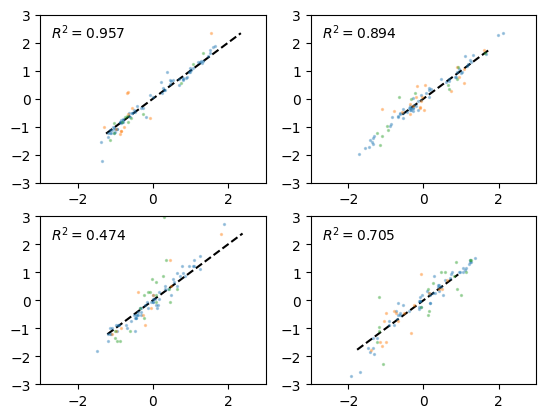

In [540]:
plot_ref_parity()

In [541]:
from torch import nn, optim
import sparsenn
from sparsenn import pareto
from copy import deepcopy

input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]

model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim, activation=nn.ReLU())
criterion = sparsenn.MultiTaskMSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

explored_values = []
frontier = []

max_epochs = int(1e5)

best_model = deepcopy(model)

lmbda_reg = 1e-5
reg_prec = 3
nwrite = 100
patience_interval = nwrite * 5
last_best = 0
best_valid = np.inf
model.train()
for epoch in range(max_epochs):
    optimizer.zero_grad()
    outputs = model(x_train)
    loss = criterion(outputs, y_train)
    reg_loss = model.regularization_loss()
    total_loss = loss + lmbda_reg * reg_loss
    total_loss.backward()
    optimizer.step()
    
    with torch.no_grad():
        outputs = model(x_valid)
        valid_loss = criterion(outputs, y_valid)
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(model)

    if reg_loss.item() < 1:
        break

    if (epoch+1) % nwrite == 0:
        with torch.no_grad():
            outputs = model(x_test)
            test_loss = criterion(outputs, y_test)
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
    
    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

Epoch 100, MSE: 0.2400, L0R: 1121.77, ValMSE: 0.3164, TestMSE: 0.4090
Epoch 200, MSE: 0.2564, L0R: 1120.03, ValMSE: 0.2977, TestMSE: 0.3352
Epoch 300, MSE: 0.2239, L0R: 1118.22, ValMSE: 0.3116, TestMSE: 0.3526
Epoch 400, MSE: 0.1818, L0R: 1118.06, ValMSE: 0.3089, TestMSE: 0.1276
Epoch 500, MSE: 0.1350, L0R: 1118.71, ValMSE: 0.2840, TestMSE: 0.2924
Epoch 600, MSE: 0.1370, L0R: 1119.65, ValMSE: 0.3237, TestMSE: 0.2168
Epoch 700, MSE: 0.1193, L0R: 1120.91, ValMSE: 0.2069, TestMSE: 0.3244
Epoch 800, MSE: 0.1036, L0R: 1122.35, ValMSE: 0.3654, TestMSE: 0.2820
Epoch 900, MSE: 0.0979, L0R: 1122.72, ValMSE: 0.2055, TestMSE: 0.2656
Epoch 1000, MSE: 0.0801, L0R: 1123.63, ValMSE: 0.2253, TestMSE: 0.3045
Epoch 1100, MSE: 0.0707, L0R: 1124.34, ValMSE: 0.1961, TestMSE: 0.2590
Epoch 1200, MSE: 0.0756, L0R: 1124.55, ValMSE: 0.2841, TestMSE: 0.2464
Epoch 1300, MSE: 0.0619, L0R: 1124.00, ValMSE: 0.2610, TestMSE: 0.2902
Epoch 1400, MSE: 0.0492, L0R: 1123.70, ValMSE: 0.1695, TestMSE: 0.3161
Epoch 1500, MSE

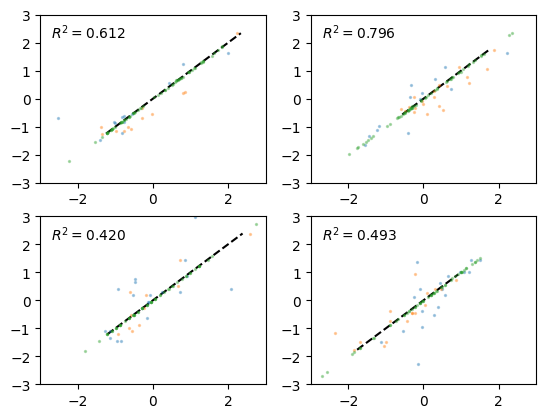

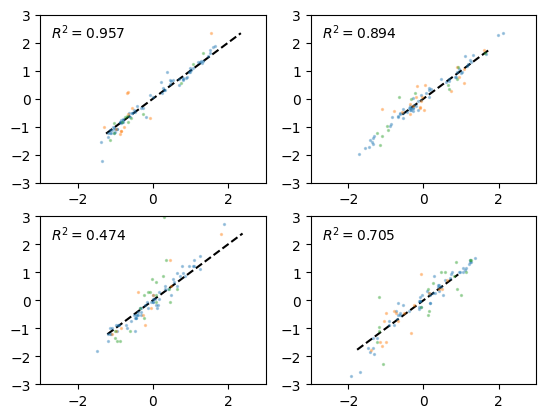

In [543]:
_ = plot_model_parity(model)
_ = plot_ref_parity()

In [544]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


class ParetoMTL:
    def __init__(self, model, num_tasks, lambda_reg=1e-5, lr=1e-2, criterion=sparsenn.MultiTaskMSELoss()):
        self.model = model
        self.num_tasks = num_tasks
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.criterion = criterion
        self.lambda_reg = lambda_reg
    
    def compute_losses(self, output, target):
        reg_loss = self.model.regularization_loss()
        losses = []
        for i in range(self.num_tasks):
            task_output = output[:, i].unsqueeze(1)
            task_target = target[:, i].unsqueeze(1)
            task_loss = self.criterion(task_output, task_target)
            total_loss = task_loss + self.lambda_reg * reg_loss / self.num_tasks
            losses.append(total_loss)
        return losses
    
    def compute_gradients(self, losses):
        grads = []
        for loss in losses:
            self.optimizer.zero_grad()
            loss.backward(retain_graph=True)
            grad = []
            for param in self.model.parameters():
                if param.grad is not None:
                    grad.append(param.grad.view(-1))
            grads.append(torch.cat(grad))
        return torch.stack(grads)
    
    def project_gradients(self, grads):
        norms = torch.norm(grads, dim=1, keepdim=True)
        normalized_grads = grads / norms
        pareto_grads = normalized_grads.mean(dim=0)
        return pareto_grads / torch.norm(pareto_grads)
    
    def apply_gradients(self, grad):
        idx = 0
        for param in self.model.parameters():
            if param.grad is not None:
                size = param.grad.numel()
                param.grad.data = grad[idx:idx+size].view_as(param.data)
                idx += size
    
    def train_step(self, inputs, targets):
        self.model.train()
        outputs = self.model(inputs)
        losses = self.compute_losses(outputs, targets)
        grads = self.compute_gradients(losses)
        pareto_grad = self.project_gradients(grads)
        self.apply_gradients(pareto_grad)
        self.optimizer.step()
        return [loss.item() for loss in losses]

input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
pareto_mtl = ParetoMTL(model, output_dim, lr=1e-2, lambda_reg=1e-5)

explored_values = []
frontier = []

best = (0, np.inf, deepcopy(model))

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pareto_mtl.train_step(x_train, y_train)

    with torch.no_grad():
        pareto_mtl.model.eval()
        reg_loss = pareto_mtl.model.regularization_loss()
        outputs = pareto_mtl.model(x_valid)
        valid_loss = criterion(outputs, y_valid)
        pareto_mtl.model.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(pareto_mtl.model)

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        pareto_mtl.model.eval()
        with torch.no_grad():
            loss = criterion(pareto_mtl.model(x_train), y_train)
            valid_loss = criterion(pareto_mtl.model(x_valid), y_valid)
            test_loss = criterion(pareto_mtl.model(x_test), y_test)
            reg_loss = pareto_mtl.model.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        pareto_mtl.model.train()
# retain the best validation loss
# model = deepcopy(best[2])

Epoch 100, MSE: 0.1713, L0R: 1127.88, ValMSE: 0.2332, TestMSE: 0.1784
Epoch 200, MSE: 0.1201, L0R: 1134.61, ValMSE: 0.1985, TestMSE: 0.1955
Epoch 300, MSE: 0.1009, L0R: 1139.62, ValMSE: 0.1612, TestMSE: 0.1482
Epoch 400, MSE: 0.0803, L0R: 1143.80, ValMSE: 0.1774, TestMSE: 0.2137
Epoch 500, MSE: 0.0756, L0R: 1147.85, ValMSE: 0.2093, TestMSE: 0.2301
Epoch 600, MSE: 0.0959, L0R: 1151.45, ValMSE: 0.2591, TestMSE: 0.2542
Epoch 700, MSE: 0.1340, L0R: 1154.62, ValMSE: 0.2982, TestMSE: 0.3081
Patience expired...


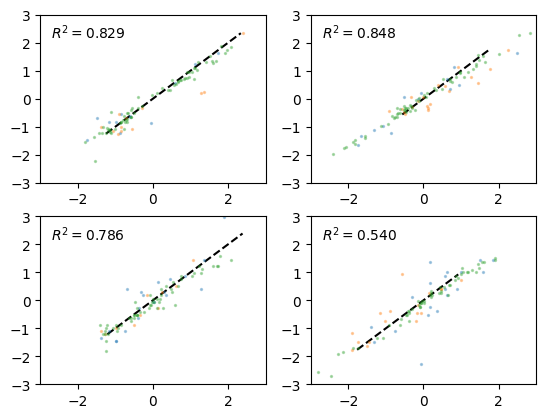

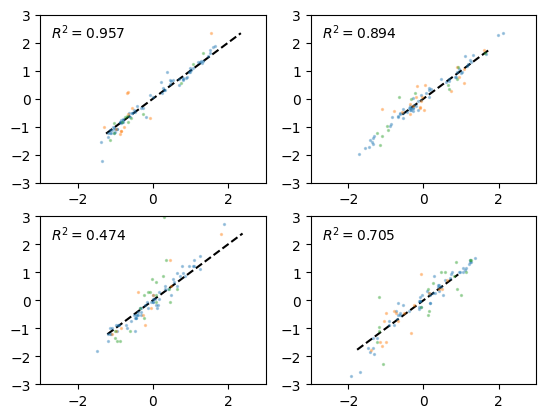

In [545]:
_ = plot_model_parity(best_model)
_ = plot_ref_parity()

In [546]:
import torch
import torch.optim as optim

class PCGrad:
    def __init__(self, model, num_tasks, optimizer, criterion, lambda_reg=0.):
        self.model = model
        self.num_tasks = num_tasks
        self.base_optimizer = optimizer
        self.criterion = criterion
        self.lambda_reg = lambda_reg
    
    def compute_losses(self, output, target):
        if self.lambda_reg > 0:
            reg_loss = self.model.regularization_loss()
        else:
            reg_loss = 0.
        losses = []
        for i in range(self.num_tasks):
            task_output = output[:, i].unsqueeze(1)
            task_target = target[:, i].unsqueeze(1)
            task_loss = self.criterion(task_output, task_target)
            total_loss = task_loss + self.lambda_reg * reg_loss / self.num_tasks
            losses.append(total_loss)
        return losses
    
    def compute_gradients(self, losses):
        grads = []
        for loss in losses:
            self.base_optimizer.zero_grad()
            loss.backward(retain_graph=True)
            grad = []
            for param in self.model.parameters():
                if param.grad is not None:
                    grad.append(param.grad.view(-1))
            grads.append(torch.cat(grad))
        return torch.stack(grads)
    
    def project_gradients(self, grads):
        proj_grads = grads.clone()
        for i in range(self.num_tasks):
            for j in range(self.num_tasks):
                if i != j:
                    inner_product = torch.dot(proj_grads[i], grads[j])
                    proj_direction = inner_product / torch.dot(grads[j], grads[j])
                    proj_grads[i] -= torch.clamp(proj_direction, min=0) * grads[j]
        return proj_grads.mean(dim=0)
    
    def apply_gradients(self, grad):
        idx = 0
        for param in self.model.parameters():
            if param.grad is not None:
                size = param.grad.numel()
                param.grad.data = grad[idx:idx+size].view_as(param.data)
                idx += size
    
    def train_step(self, inputs, targets):
        self.model.train()
        outputs = self.model(inputs)
        losses = self.compute_losses(outputs, targets)
        grads = self.compute_gradients(losses)
        pcgrad = self.project_gradients(grads)
        self.apply_gradients(pcgrad)
        self.base_optimizer.step()
        return [loss.item() for loss in losses]
    
    
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
pcgrad_mtl = PCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)

best = (0, np.inf, deepcopy(model))

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    if (epoch+1) % n_write == 0:
        m = pcgrad_mtl.model
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        if valid_loss < best[1]:
            best = (epoch, valid_loss, deepcopy(m))
        if epoch - best[0] > patience_interval:
            print('Patience expired...')
            break
        m.train()
# retain the best validation loss
model = deepcopy(best[2])    

Epoch 100, MSE: 0.1693, L0R: 1130.93, ValMSE: 0.2364, TestMSE: 0.2000
Epoch 200, MSE: 0.1177, L0R: 1136.52, ValMSE: 0.1939, TestMSE: 0.1761
Epoch 300, MSE: 0.0886, L0R: 1142.91, ValMSE: 0.2097, TestMSE: 0.1819
Epoch 400, MSE: 0.0815, L0R: 1147.09, ValMSE: 0.1764, TestMSE: 0.1961
Epoch 500, MSE: 0.0673, L0R: 1152.27, ValMSE: 0.2619, TestMSE: 0.1838
Epoch 600, MSE: 0.1078, L0R: 1156.68, ValMSE: 0.2502, TestMSE: 0.2366
Epoch 700, MSE: 0.0735, L0R: 1159.95, ValMSE: 0.2756, TestMSE: 0.2134
Epoch 800, MSE: 0.0867, L0R: 1162.62, ValMSE: 0.2611, TestMSE: 0.2320
Epoch 900, MSE: 0.0614, L0R: 1165.34, ValMSE: 0.3019, TestMSE: 0.2243
Epoch 1000, MSE: 0.0495, L0R: 1167.70, ValMSE: 0.2998, TestMSE: 0.2197
Patience expired...


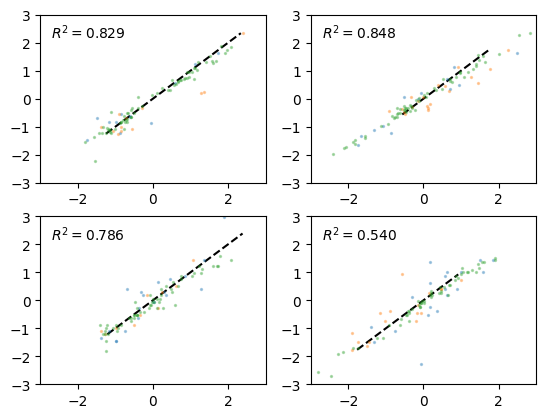

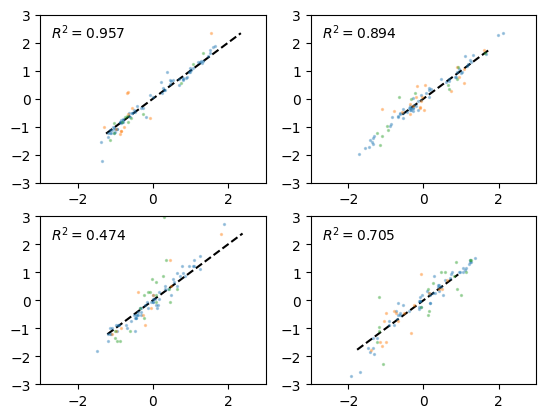

In [547]:
_ = plot_model_parity(best_model)
_ = plot_ref_parity()

In [548]:
input_dim = x_train.shape[1]
hidden_dim = (32, 32, 32, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
pcgrad_mtl = PCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)

explored_values = []
frontier = []

best = (0, np.inf, deepcopy(model))

last_best = 0
last_valid_best = 0

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs, y_valid)
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.1349, L0R: 3049.83, ValMSE: 0.1925, TestMSE: 0.1774
Epoch 200, MSE: 0.0858, L0R: 3055.93, ValMSE: 0.2332, TestMSE: 0.1462
Epoch 300, MSE: 0.0534, L0R: 3061.14, ValMSE: 0.1731, TestMSE: 0.2039
Epoch 400, MSE: 0.0818, L0R: 3066.93, ValMSE: 0.2434, TestMSE: 0.2329
Epoch 500, MSE: 0.0557, L0R: 3070.03, ValMSE: 0.1903, TestMSE: 0.2312
Epoch 600, MSE: 0.0486, L0R: 3074.36, ValMSE: 0.2094, TestMSE: 0.2538
Epoch 700, MSE: 0.0378, L0R: 3077.05, ValMSE: 0.1539, TestMSE: 0.2471
Epoch 800, MSE: 0.0551, L0R: 3079.53, ValMSE: 0.2060, TestMSE: 0.2997
Epoch 900, MSE: 0.0416, L0R: 3081.39, ValMSE: 0.2069, TestMSE: 0.2563
Epoch 1000, MSE: 0.0460, L0R: 3084.49, ValMSE: 0.2101, TestMSE: 0.2731
Epoch 1100, MSE: 0.0291, L0R: 3085.18, ValMSE: 0.1817, TestMSE: 0.2652
Epoch 1200, MSE: 0.0549, L0R: 3086.98, ValMSE: 0.2222, TestMSE: 0.2816
Patience expired...


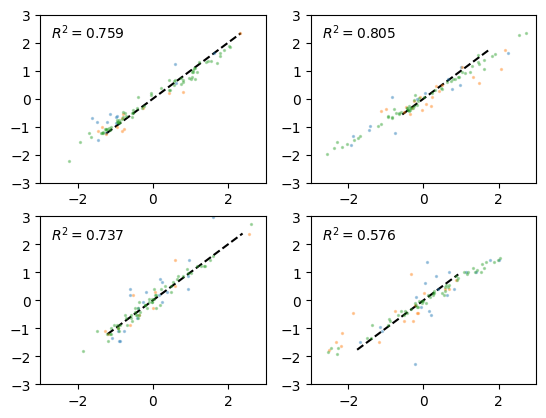

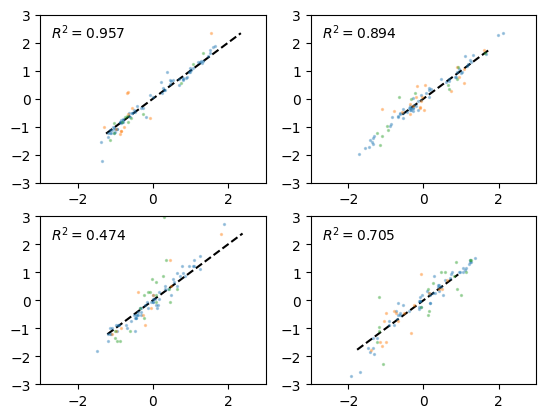

In [550]:
_ = plot_model_parity(pcgrad_mtl.model)
_ = plot_ref_parity()

In [551]:
import torch

class wPCGrad(PCGrad):
    def __init__(self, model, num_tasks, optimizer, criterion, lambda_reg=0., task_weights=None):
        super().__init__(model, num_tasks, optimizer, criterion, lambda_reg)
        if task_weights is None:
            self.task_weights = torch.ones(num_tasks) / num_tasks
        else:
            self.task_weights = task_weights 
    
    def update_task_weights(self, new_weights):
        self.task_weights = new_weights
    
    def project_gradients(self, grads):
        proj_grads = grads.clone()
        
        # Sample a task to remain unmodified based on task weights
        unmodified_task = torch.multinomial(self.task_weights, 1).item()
        
        for i in range(self.num_tasks):
            if i != unmodified_task:
                inner_product = torch.dot(proj_grads[i], grads[unmodified_task])
                if inner_product < 0:
                    proj_direction = inner_product / torch.dot(grads[unmodified_task], grads[unmodified_task])
                    proj_grads[i] -= proj_direction * grads[unmodified_task]
        
        return proj_grads.mean(dim=0)
    
    def train_step(self, inputs, targets):
        self.model.train()
        outputs = self.model(inputs)
        losses = self.compute_losses(outputs, targets)
        grads = self.compute_gradients(losses)
        wpcgrad = self.project_gradients(grads)
        self.apply_gradients(wpcgrad)
        self.base_optimizer.step()
        return [loss.item() for loss in losses]

In [552]:
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
tw = torch.tensor([0.01, 0.01, 0.97, 0.01]).float()
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5, task_weights=tw)

explored_values = []
frontier = []

best = (0, np.inf, deepcopy(model))

last_best = 0
last_valid_best = 0

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs, y_valid)
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.1915, L0R: 1131.07, ValMSE: 0.2623, TestMSE: 0.2211
Epoch 200, MSE: 0.1076, L0R: 1138.53, ValMSE: 0.2224, TestMSE: 0.1622
Epoch 300, MSE: 0.0940, L0R: 1143.33, ValMSE: 0.2657, TestMSE: 0.1355
Epoch 400, MSE: 0.0724, L0R: 1148.91, ValMSE: 0.2284, TestMSE: 0.1880
Epoch 500, MSE: 0.0610, L0R: 1153.28, ValMSE: 0.2136, TestMSE: 0.2079
Epoch 600, MSE: 0.0695, L0R: 1157.71, ValMSE: 0.2137, TestMSE: 0.2567
Epoch 700, MSE: 0.0736, L0R: 1161.33, ValMSE: 0.1935, TestMSE: 0.2047
Epoch 800, MSE: 0.0546, L0R: 1163.41, ValMSE: 0.2182, TestMSE: 0.2301
Epoch 900, MSE: 0.0447, L0R: 1166.30, ValMSE: 0.1811, TestMSE: 0.2231
Epoch 1000, MSE: 0.0748, L0R: 1169.42, ValMSE: 0.2859, TestMSE: 0.2391
Epoch 1100, MSE: 0.0572, L0R: 1171.87, ValMSE: 0.2017, TestMSE: 0.2269
Epoch 1200, MSE: 0.0396, L0R: 1174.12, ValMSE: 0.2271, TestMSE: 0.2309
Epoch 1300, MSE: 0.0625, L0R: 1176.27, ValMSE: 0.2835, TestMSE: 0.2506
Epoch 1400, MSE: 0.0300, L0R: 1177.53, ValMSE: 0.2128, TestMSE: 0.2508
Patience expire

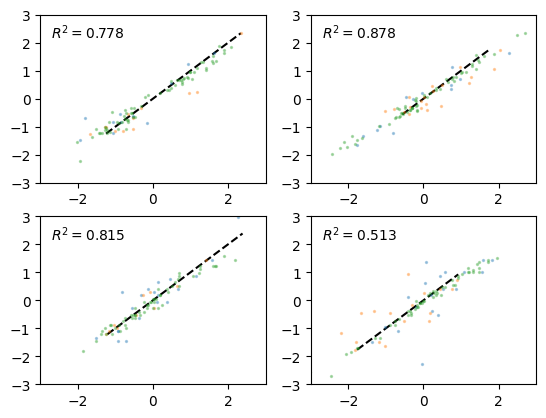

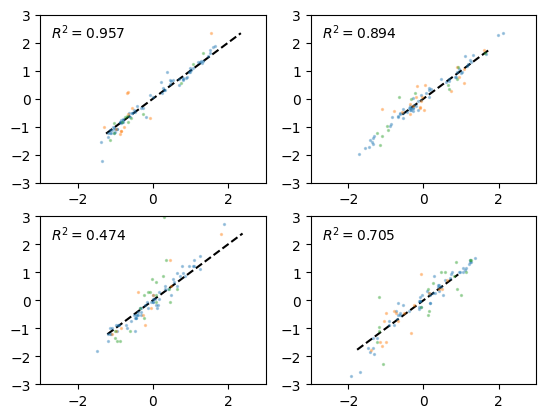

In [553]:
_ = plot_model_parity(pcgrad_mtl.model)
_ = plot_ref_parity()

In [554]:
class DynamicTaskPrioritization:
    def __init__(self, num_tasks, gamma=2, epsilon=1e-8):
        self.num_tasks = num_tasks
        self.gamma = gamma
        self.epsilon = epsilon
        self.task_losses = np.zeros(num_tasks)
        self.task_weights = np.ones(num_tasks) / num_tasks

    def update_task_losses(self, new_losses):
        """
        Update the task losses with the latest values.
        :param new_losses: List or numpy array of new loss values for each task
        """
        self.task_losses = np.array(new_losses)

    def compute_weights(self):
        """
        Compute new task weights based on the current task losses.
        """
        # Avoid division by zero
        adjusted_losses = self.task_losses + self.epsilon
        
        # Compute weights according to the formula in the paper
        weights = adjusted_losses ** self.gamma
        normalized_weights = weights / np.sum(weights)
        
        self.task_weights = normalized_weights
        return self.task_weights

    def get_torch_weights(self):
        """
        Return the current weights as a PyTorch tensor.
        """
        return torch.FloatTensor(self.task_weights)

In [555]:
input_dim = x_train.shape[1]
hidden_dim = (16, 16, 16, )
output_dim = y_train.shape[1]
model = sparsenn.RegularizedMLPwithSkips(input_dim, hidden_dim, output_dim)
optimizer = optim.Adam(model.parameters(), lr=1e-2)
pcgrad_mtl = wPCGrad(model, output_dim, optimizer, criterion, lambda_reg=1e-5)
dtp = DynamicTaskPrioritization(output_dim)
task_priority = [2]

explored_values = []
frontier = []

last_best = 0
last_valid_best = 0

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 5 * n_write
for epoch in range(num_epochs):
    losses = pcgrad_mtl.train_step(x_train, y_train)
    
    dtp.update_task_losses(losses)
    new_weights = dtp.compute_weights()
    pcgrad_mtl.update_task_weights(dtp.get_torch_weights())

    m = pcgrad_mtl.model
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs, y_valid)
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train), y_train)
            valid_loss = criterion(m(x_valid), y_valid)
            test_loss = criterion(m(x_test), y_test)
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.1647, L0R: 1130.83, ValMSE: 0.2308, TestMSE: 0.1876
Epoch 200, MSE: 0.1171, L0R: 1136.25, ValMSE: 0.2243, TestMSE: 0.1663
Epoch 300, MSE: 0.1012, L0R: 1141.81, ValMSE: 0.2095, TestMSE: 0.1778
Epoch 400, MSE: 0.1195, L0R: 1147.12, ValMSE: 0.2187, TestMSE: 0.2089
Epoch 500, MSE: 0.0796, L0R: 1151.47, ValMSE: 0.2477, TestMSE: 0.1728
Epoch 600, MSE: 0.0903, L0R: 1156.14, ValMSE: 0.1979, TestMSE: 0.2347
Epoch 700, MSE: 0.0877, L0R: 1159.27, ValMSE: 0.2711, TestMSE: 0.2262
Epoch 800, MSE: 0.1048, L0R: 1161.86, ValMSE: 0.2550, TestMSE: 0.2421
Epoch 900, MSE: 0.0853, L0R: 1164.59, ValMSE: 0.2441, TestMSE: 0.2343
Epoch 1000, MSE: 0.0630, L0R: 1167.16, ValMSE: 0.2740, TestMSE: 0.2540
Epoch 1100, MSE: 0.0533, L0R: 1170.19, ValMSE: 0.2630, TestMSE: 0.2930
Epoch 1200, MSE: 0.0579, L0R: 1171.98, ValMSE: 0.2669, TestMSE: 0.3070
Patience expired...


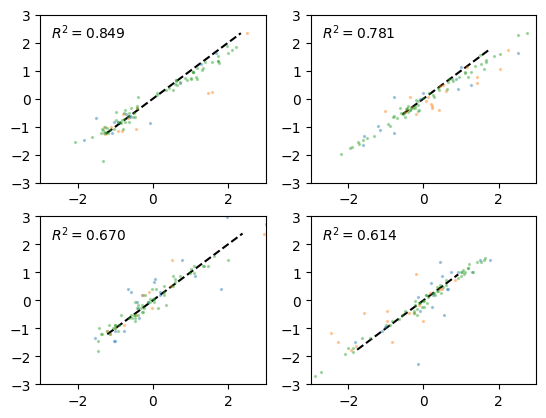

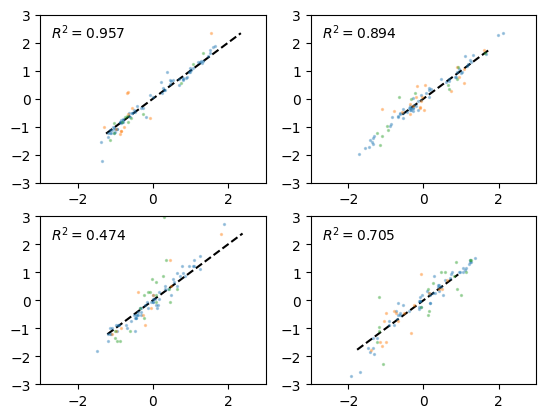

In [556]:
_ = plot_model_parity(pcgrad_mtl.model)
_ = plot_ref_parity()

In [557]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

class LWFRegression(object):
    def __init__(self, model, num_tasks, lr=1e-2, criterion=sparsenn.MultiTaskMSELoss(), lwf_lambda=1.0):
        self.model = model
        self.num_tasks = num_tasks
        self.optimizer = optim.Adam(model.parameters(), lr=lr)
        self.criterion = criterion
        self.lwf_lambda = lwf_lambda
        self.old_model = None
    
    def prepare_lwf(self):
        # Create a copy of the current model to serve as the "old" model
        self.old_model = copy.deepcopy(self.model)
        self.old_model.eval()
    
    def compute_lwf_loss(self, inputs, target_task):
        # Get outputs from the old model
        with torch.no_grad():
            old_outputs = self.old_model(inputs)
        
        # Get outputs from the current model
        current_outputs = self.model(inputs)
        
        lwf_loss = 0
        for task in range(self.num_tasks):
            if task != target_task:
                # Use MSE for regression tasks
                lwf_loss += self.criterion(
                    current_outputs[:, task].unsqueeze(1),
                    old_outputs[:, task].unsqueeze(1)
                )
        
        return lwf_loss
    
    def fine_tune_step(self, inputs, targets, target_task):
        self.model.train()
        outputs = self.model(inputs)

        # If 2D, we select the target task column
        target_loss = self.criterion(outputs[:, target_task].unsqueeze(1), targets[:, target_task].unsqueeze(1))
        
        # Compute the LWF loss
        lwf_loss = self.compute_lwf_loss(inputs, target_task)
        
        # Combine the losses
        total_loss = target_loss + self.lwf_lambda * lwf_loss
        
        # Compute gradients and update the model
        self.optimizer.zero_grad()
        total_loss.backward()
        self.optimizer.step()
        
        return total_loss.item(), target_loss.item(), lwf_loss.item()

In [560]:
lwf_trainer = LWFRegression(deepcopy(pcgrad_mtl.model), output_dim, lr=1e-2, lwf_lambda=0.1)
lwf_trainer.prepare_lwf()
target_task = 0

# Training loop
num_epochs = int(1e5)
n_write = 100
patience_interval = 10 * n_write
for epoch in range(num_epochs):
    total_loss, target_loss, lwf_loss = lwf_trainer.fine_tune_step(x_train, y_train, target_task)

    m = lwf_trainer.model
    
    # BOILERPLATE
    with torch.no_grad():
        m.eval()
        reg_loss = m.regularization_loss()
        outputs = m(x_valid)
        valid_loss = criterion(outputs[:, target_task], y_valid[:, target_task])
        m.train()
    
    point = np.array([valid_loss.item(), np.round(reg_loss.item(), reg_prec)])
    explored_values.append(point)
    if not pareto.is_dominated(point, frontier):
        frontier = pareto.update_pareto_front(point, frontier)
        last_best = epoch

        if valid_loss < best_valid:
            best_valid = valid_loss
            best_model = deepcopy(m)
            last_valid_best = epoch

    if reg_loss.item() < 1:
        break

    if epoch - last_best > patience_interval:
        print('Patience expired...')
        break

    if epoch - last_valid_best > 10 * patience_interval:
        print('Meta-Patience expired...')
        break

    if (epoch+1) % n_write == 0:
        m.eval()
        with torch.no_grad():
            loss = criterion(m(x_train)[:, target_task], y_train[:, target_task])
            valid_loss = criterion(m(x_valid)[:, target_task], y_valid[:, target_task])
            test_loss = criterion(m(x_test)[:, target_task], y_test[:, target_task])
            reg_loss = m.regularization_loss()
        print(f'Epoch {epoch+1}, MSE: {loss.item():.4f}, L0R: {reg_loss.item():.2f}, ValMSE: {valid_loss.item():.4f}, TestMSE: {test_loss.item():.4f}')
        m.train()

Epoch 100, MSE: 0.0495, L0R: 1172.24, ValMSE: 0.1829, TestMSE: 0.1109
Epoch 200, MSE: 0.0308, L0R: 1174.25, ValMSE: 0.1893, TestMSE: 0.1575
Epoch 300, MSE: 0.0110, L0R: 1174.89, ValMSE: 0.2442, TestMSE: 0.0918
Epoch 400, MSE: 0.0105, L0R: 1176.05, ValMSE: 0.2591, TestMSE: 0.1574
Epoch 500, MSE: 0.0249, L0R: 1176.89, ValMSE: 0.2178, TestMSE: 0.1570
Epoch 600, MSE: 0.0136, L0R: 1177.06, ValMSE: 0.2640, TestMSE: 0.1197
Epoch 700, MSE: 0.0176, L0R: 1177.39, ValMSE: 0.2620, TestMSE: 0.0877
Epoch 800, MSE: 0.0102, L0R: 1178.01, ValMSE: 0.2613, TestMSE: 0.0618
Epoch 900, MSE: 0.0063, L0R: 1178.34, ValMSE: 0.2974, TestMSE: 0.0732
Epoch 1000, MSE: 0.0081, L0R: 1178.75, ValMSE: 0.3041, TestMSE: 0.0955
Epoch 1100, MSE: 0.0077, L0R: 1179.42, ValMSE: 0.2739, TestMSE: 0.1076
Patience expired...


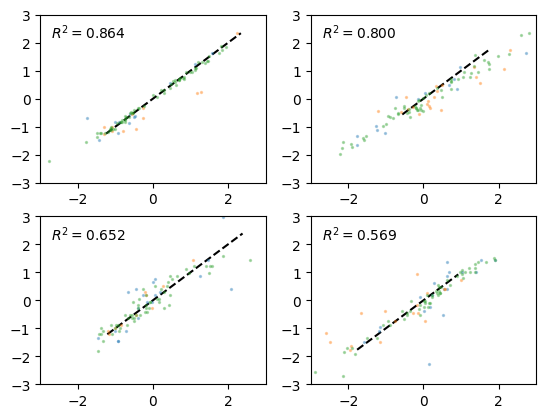

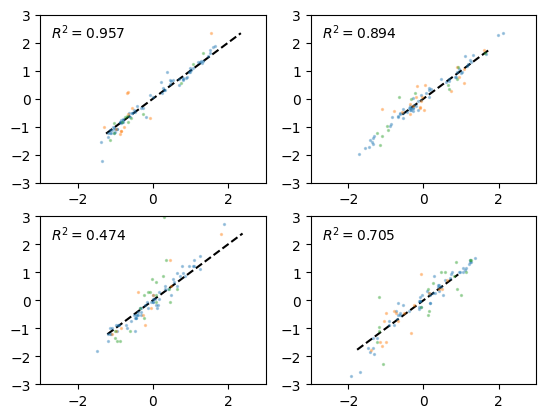

In [561]:
_ = plot_model_parity(lwf_trainer.model)
_ = plot_ref_parity()